<a href="https://colab.research.google.com/github/tmorenom/MyRep_TMM2025/blob/main/Actividad4EDA_A01840597.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**MAESTRÍA EN INTELIGENCIA ARTIFICIAL APLICADA**

**Curso: TC5053 - Ciencia y analítica de datos**

Tecnológico de Monterrey

Prof Grettel Barceló Alonso

**Semana 4**
Exploración de datos

---

*   NOMBRE: TERESA DE JESUS MORENO MARTINEZ
*   MATRÍCULA: A01840597

En esta actividad trabajarás con el archivo `personal_loan.csv`, basado en un conjunto de datos sobre clientes bancarios y su comportamiento financiero disponible en Kaggle.

Los datos fueron recopilados para analizar la posibilidad de que los clientes acepten un préstamo personal y contienen información demográfica, financiera y de productos bancarios asociados. Los indicadores incluidos son:

* `ID`: Identificador único del cliente
* `Age`: Edad del cliente (años completos)
* `Experience`: Experiencia laboral en años
* `Income`: Ingreso anual del cliente (en miles de dólares. Por ejemplo, 60 = 60,000 USD/año)
* `ZIP Code`: Código postal del cliente
* `Family`: Número de miembros de la familia
* `CCAvg`: Promedio de gastos mensuales con tarjeta de crédito (en miles de dólares)
* `Education`: Nivel educativo (1 = graduado, 2 = universitario, 3 = posgrado)
* `Mortgage`: Monto de hipoteca que posee el cliente (en miles de dólares)
* `Securities Account`: Indicador de si tiene cuenta de valores (1 = sí, 0 = no)
* `CD Account`: Indicador de si tiene cuenta de certificado de depósito (1 = sí, 0 = no)
* `Online`: Indicador de si usa los servicios bancarios en línea (1 = sí, 0 = no)
* `CreditCard`: Indicador de si es titular de tarjeta de crédito (1 = sí, 0 = no)
* `Personal Loan`: Si el cliente aceptó (1) o no (0) un préstamo personal. Es la variable de salida o *target*, es decir, la que se pretende predecir más adelante al construir el modelo

**NOTA IMPORTANTE:** Asegúrate de responder *explícitamente* todos los cuestionamientos.

In [1]:
# Importar las bibliotecas necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm

1. Descarga el archivo: `personal_loan.csv` y guarda, en un dataframe (`loan_df`), todos sus registros.
* Haz que la columna `ID` sea el índice del dataframe.
* Utiliza el método `info()` del dataframe, para obtener el resumen de los tipos de datos. ¿Cuántas columnas son numéricas y cuántas de texto?

In [2]:
Persloan_df = pd.read_csv('personal_loan.csv')
Persloan_df = Persloan_df.set_index('ID')

print('Resumen de los tipos de datos:')
Persloan_df.info()

# Cuántas columnas son númericas y cuántas son de texto
Col_nums = Persloan_df.select_dtypes(include=np.number).columns
Col_texto = Persloan_df.select_dtypes(include='object').columns

print(f"\nNúmero de columnas numéricas: {len(Col_nums)}")
print(f"Número de columnas de texto: {len(Col_texto)}")

Resumen de los tipos de datos:
<class 'pandas.core.frame.DataFrame'>
Index: 5037 entries, 0 to 5036
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Age                 5037 non-null   int64  
 1   Experience          5037 non-null   int64  
 2   Income              5037 non-null   int64  
 3   ZIP Code            5037 non-null   int64  
 4   Family              5037 non-null   int64  
 5   CCAvg               5037 non-null   float64
 6   Education           5037 non-null   float64
 7   Mortgage            5037 non-null   int64  
 8   Personal Loan       5037 non-null   object 
 9   Securities Account  5037 non-null   object 
 10  CD Account          5037 non-null   object 
 11  Online              5037 non-null   object 
 12  CreditCard          5037 non-null   object 
dtypes: float64(2), int64(6), object(5)
memory usage: 550.9+ KB

Número de columnas numéricas: 8
Número de columnas de texto: 5


# Limpieza

2. Obtén las estadísticas descriptivas de las variables numéricas y examina cuidadosamente los valores obtenidos de cada columna.
* Filtra el dataframe para visualizar los registros en que la edad supera los 100 años y elimínalos si no son pausibles.
* Analiza el resto de las variables y elimina aquellos registros que contengan valores inválidos o inconsistentes. Para cada acción que realices, justifica la decisión, explicando por qué consideras que el valor es incorrecto.
* ¿Cuántos registros se eliminaron (considerando todas las acciones de este ejercicio) y qué porcentaje representa respecto al total del dataframe inicial?

In [3]:
# Obtén las estadísticas descriptivas de las variables numéricas y examina cuidadosamente
# los valores obtenidos de cada columna.
print("Estadísticas descriptivas de las variables numéricas:")
print(Persloan_df[Col_nums].describe())

Col_nums = Persloan_df.select_dtypes(include=np.number).columns


print("\nCoeficiente de asimetría de las columnas numéricas:")
print(Persloan_df[Col_nums].skew())

print("\nCoeficiente de curtosis de las columnas numéricas:")
print(Persloan_df[Col_nums].kurtosis())

#Filtra el dataframe para visualizar los registros en que la edad supera los 100 años
#y elimínalos si no son pausibles.

print(f"Registros en que la edad es mayor a 100 años: {len(Persloan_df[Persloan_df['Age'] > 100])}")
Persloan_df = Persloan_df[Persloan_df['Age'] <= 100]
print(f"Registros donde la edad es mayor a 100 años quitando los no pausibles: {len(Persloan_df[Persloan_df['Age'] > 100])}")
print(f"Numero de regustros después de la limpieza: {len(Persloan_df)}")

# Se remueven los regstros en donde la Experiencia es mayor que la edad
# Es incongruente que tenga mas experiencia que edad por eso se limpian estos registros
Persloan_df = Persloan_df[(Persloan_df['Experience'] >= 0) & (Persloan_df['Experience'] <= Persloan_df['Age'])]

#Se remuven registros en donde el ingreso sea cero o negativo
#La razón es porque se está analizando con base también a la economía y no aportan nada estos registros
Persloan_df = Persloan_df[Persloan_df['Income'] > 0]

# Se remueven los registros en donde la educación presenta un rango inválido (1, 2, or 3)
Persloan_df = Persloan_df[Persloan_df['Education'].isin([1, 2, 3])]

# Removiendo registros duplicados
Persloan_df.drop_duplicates(inplace=True)

# Se corrige el número de índice para mantener la consistencia despues de eliminar duplicados
Persloan_df.reset_index(drop=True, inplace=True)

# Se comparan los registros eliminados
reg_iniciales = 5037
reg_eliminados = reg_iniciales - len(Persloan_df)
porc_eliminados = (reg_eliminados / reg_iniciales) * 100

print(f"\nTotal de registros eliminados: {reg_eliminados}")
print(f"Porcentaje de registros eliminadoos: {porc_eliminados:.2f}%")

#Se muestra cabecero y data frame final
print(Persloan_df.head())
print(Persloan_df.dtypes)

Estadísticas descriptivas de las variables numéricas:
               Age   Experience       Income      ZIP Code       Family  \
count  5037.000000  5037.000000  5037.000000   5037.000000  5037.000000   
mean     45.411356    20.122494    73.898352  93152.865595     2.394679   
std      11.646805    11.461278    46.130504   2119.637960     1.151145   
min      23.000000    -3.000000     8.000000   9307.000000    -3.000000   
25%      35.000000    10.000000    39.000000  91911.000000     1.000000   
50%      45.000000    20.000000    64.000000  93437.000000     2.000000   
75%      55.000000    30.000000    98.000000  94608.000000     3.000000   
max     144.000000    43.000000   224.000000  96651.000000     4.000000   

             CCAvg    Education     Mortgage  
count  5037.000000  5037.000000  5037.000000  
mean      1.942404     1.880941    56.500695  
std       1.755954     0.843337   101.657580  
min       0.000000     1.000000     0.000000  
25%       0.700000     1.000000    

3. Obtén las estadísticas descriptivas de las variables de texto e imprime las frecuencias de sus categorías.
* Algunas columnas almacenan valores binarios utilizando distintos formatos. Unifica estos valores de manera consistente, asegurándote de que coincidan con la descripción de las variables al inicio de esta libreta.

In [4]:
print("Estadísticas descriptivas de las variables numéricas:")
print(Persloan_df[Col_nums].describe())
print("\nFrecuencias:")
text_cat_cols = Persloan_df.select_dtypes(include=['object', 'category']).columns.tolist()

for col in text_cat_cols:
    print(f"\n--- {col} ---")
    print(Persloan_df[col].value_counts())

colsbin_a_unif = ['Personal Loan', 'Securities Account', 'CD Account', 'Online', 'CreditCard']

for col in colsbin_a_unif:
    Persloan_df[col] = Persloan_df[col].astype(str)
    mapping = {'Yes': '1', 'No': '0', '1': '1', '0': '0'}
    Persloan_df[col] = Persloan_df[col].replace(mapping)
    Persloan_df[col] = Persloan_df[col].astype(int)
    Persloan_df[col] = Persloan_df[col].astype('category')

print("Columnas binarias unificadas y convertidas:")
for col in colsbin_a_unif:
    print(f"\n--- {col} (dtype: {Persloan_df[col].dtype}) ---")
    print(Persloan_df[col].value_counts())

Estadísticas descriptivas de las variables numéricas:
               Age   Experience       Income      ZIP Code       Family  \
count  4944.000000  4944.000000  4944.000000   4944.000000  4944.000000   
mean     45.563107    20.336974    73.823625  93150.614482     2.390170   
std      11.314587    11.306309    46.122628   2127.250392     1.151692   
min      24.000000     0.000000     8.000000   9307.000000    -3.000000   
25%      36.000000    11.000000    39.000000  91910.750000     1.000000   
50%      46.000000    20.000000    64.000000  93437.000000     2.000000   
75%      55.000000    30.000000    98.000000  94608.000000     3.000000   
max      67.000000    43.000000   224.000000  96651.000000     4.000000   

             CCAvg    Education     Mortgage  
count  4944.000000  4944.000000  4944.000000  
mean      1.935975     1.878641    56.629248  
std       1.748313     0.839687   101.853990  
min       0.000000     1.000000     0.000000  
25%       0.700000     1.000000    

4. Verifica si hay registros duplicados y si fuera así, elimínalos del dataframe.
* Asegúrate de reiniciar el índice para mantener una secuencia continua tras todas las eliminaciones de registros que hasta este punto se han realizado.

In [5]:
print(f"Número de registros duplicados: {Persloan_df.duplicated().sum()}")
Persloan_df.drop_duplicates(inplace=True)
print(f"Número de registros duplicados (validación): {Persloan_df.duplicated().sum()}")

# Reinicio de índice para corrección de secuencia
Persloan_df.reset_index(drop=True, inplace=True)

print("\nNúmero actual de registros duplicados y reinicio de índice: {len(Persloan_df)}")
print(Persloan_df.head())

Número de registros duplicados: 0
Número de registros duplicados (validación): 0

Número actual de registros duplicados y reinicio de índice: {len(Persloan_df)}
   Age  Experience  Income  ZIP Code  Family  CCAvg  Education  Mortgage  \
0   25           1      49     91108       4    1.6        1.0         0   
1   45          19      34     90089       3    1.5        1.0         0   
2   39          15      11     94720       1    1.0        1.0         0   
3   35           9     100     94112       1    2.7        2.0         0   
4   35           8      45     91330       4    1.0        2.0         0   

  Personal Loan Securities Account CD Account Online CreditCard  
0             0                  1          0      0          0  
1             0                  1          0      0          0  
2             0                  0          0      0          0  
3             0                  0          0      0          0  
4             0                  0          0      0

5. Aunque hasta ahora se han considerado los tipos de datos inferidos por pandas, antes del EDA es recomendable revisar la naturaleza estadística de cada variable (continua, discreta, categórica, binaria, etc.) para aplicar el análisis adecuado.

* Efectúa las siguientes conversiones:
  - Nominal: ZIP Code - `object`
  - Ordinal: Education - `category` con orden 1, 2, 3
  - Binarias: Personal Loan, Securities Account, CD Account, Online, CreditCard - `category`
* Crea dos listas llamadas `num_cols` y `cat_cols` que contengan los nombres de las variables numéricas (int64, float64) y categóricas (object, category) del dataset, respectivamente.

In [6]:
#Conversiones de ZIP Code, Education y Binarias
Persloan_df['ZIP Code'] = Persloan_df['ZIP Code'].astype('object')
Persloan_df['Education'] = pd.Categorical(Persloan_df['Education'], categories=[1.0, 2.0, 3.0], ordered=True)
colsbin_cat = ['Personal Loan', 'Securities Account', 'CD Account', 'Online', 'CreditCard']
for col in colsbin_cat:
    Persloan_df[col] = Persloan_df[col].astype('category')

print("Tipo de datos después de la conversión:")
print(Persloan_df.dtypes)

num_cols = Persloan_df.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = Persloan_df.select_dtypes(include=['object', 'category']).columns.tolist()

print(f"\nColumnas númericas (num_cols): {num_cols}")
print(f"Categoría Columnas (cat_cols): {cat_cols}")

Tipo de datos después de la conversión:
Age                      int64
Experience               int64
Income                   int64
ZIP Code                object
Family                   int64
CCAvg                  float64
Education             category
Mortgage                 int64
Personal Loan         category
Securities Account    category
CD Account            category
Online                category
CreditCard            category
dtype: object

Columnas númericas (num_cols): ['Age', 'Experience', 'Income', 'Family', 'CCAvg', 'Mortgage']
Categoría Columnas (cat_cols): ['ZIP Code', 'Education', 'Personal Loan', 'Securities Account', 'CD Account', 'Online', 'CreditCard']


# Análisis exploratorio de datos (univariado)

6. Para el análisis de las variables numéricas obtén nuevamente las estadísticas descriptivas incluyendo los valores de simetría y curtosis.
* Clasifica las variables `Age`, `Income` y `Mortgage` según los valores observados de asimetría y curtosis.

In [7]:
print("Estadísticas descriptivas:")
print(Persloan_df[num_cols].describe())

print("\nCoeficiente de asimetría de las columnas numéricas:")
print(Persloan_df[num_cols].skew())

print("\nCoeficiente de curtosis de las columnas numéricas:")
print(Persloan_df[num_cols].kurtosis())

print("\nClasificación de Variables según los valores observados en Edad:")
print(f"El resultado de la Asimetría es casi 0 lo que indica que la distribución de la edad es simétrica")
print(f"El resultado de la Curtosis es < 1, lo que indica que la distribución es menor a una distribución normal")

print("\nClasificación de Variables según los valores observados en Ingresos:")
print(f"El resultado de la Asimetría es Positiva lo que indica que la distribución es ligeramente sesgada a la derecha")
print(f"El resultado de la Curtosis es cercana a 0, lo que indica que la distribución es normal")

print("\nClasificación de Variables según los valores observados en Hipoteca:")
print(f"El resultado de la Asimetría es Positiva lo que indica que la distribución es mayormente sesgada a la derecha")
print(f"El resultado de la Curtosis es > a 1, lo que indica que la distribución es normal")


Estadísticas descriptivas:
               Age   Experience       Income       Family        CCAvg  \
count  4944.000000  4944.000000  4944.000000  4944.000000  4944.000000   
mean     45.563107    20.336974    73.823625     2.390170     1.935975   
std      11.314587    11.306309    46.122628     1.151692     1.748313   
min      24.000000     0.000000     8.000000    -3.000000     0.000000   
25%      36.000000    11.000000    39.000000     1.000000     0.700000   
50%      46.000000    20.000000    64.000000     2.000000     1.500000   
75%      55.000000    30.000000    98.000000     3.000000     2.600000   
max      67.000000    43.000000   224.000000     4.000000    10.000000   

          Mortgage  
count  4944.000000  
mean     56.629248  
std     101.853990  
min       0.000000  
25%       0.000000  
50%       0.000000  
75%     101.000000  
max     635.000000  

Coeficiente de asimetría de las columnas numéricas:
Age          -0.023095
Experience   -0.015539
Income        0.84

7. Genera un histograma para cada variable numérica, incluyendo la curva KDE y la curva de una distribución normal como referencia.
* Para las variables que clasificaste antes, compara los histogramas generados con los valores numéricos calculados y comenta si la forma de cada distribución coincide con lo esperado.
* Para cada variable, crea un gráfico de boxplot individual que incluya la media.
* Analiza la posición de la media respecto a la mediana. ¿Qué indica esta relación sobre el sesgo (asimetría) de la distribución?

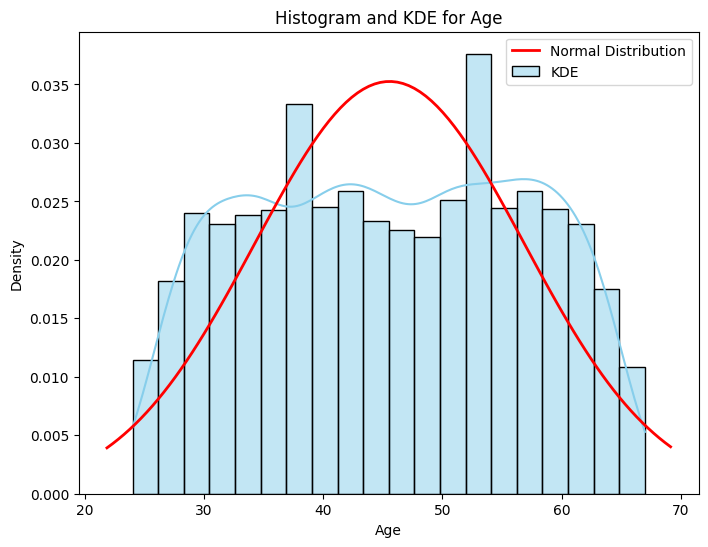

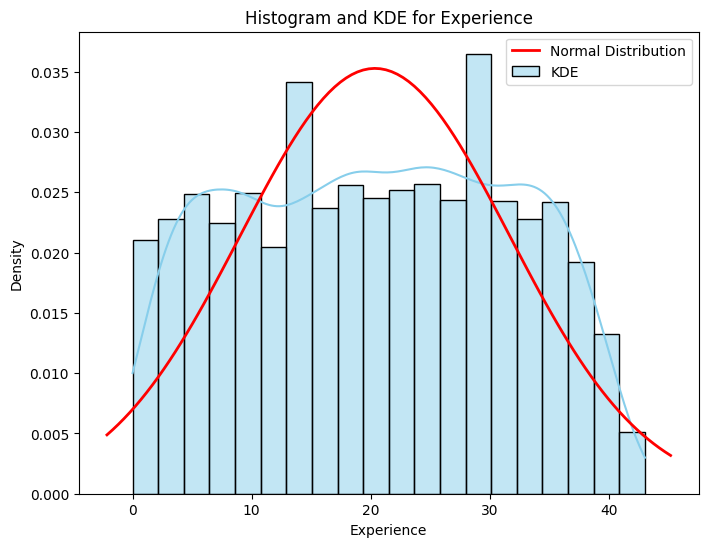

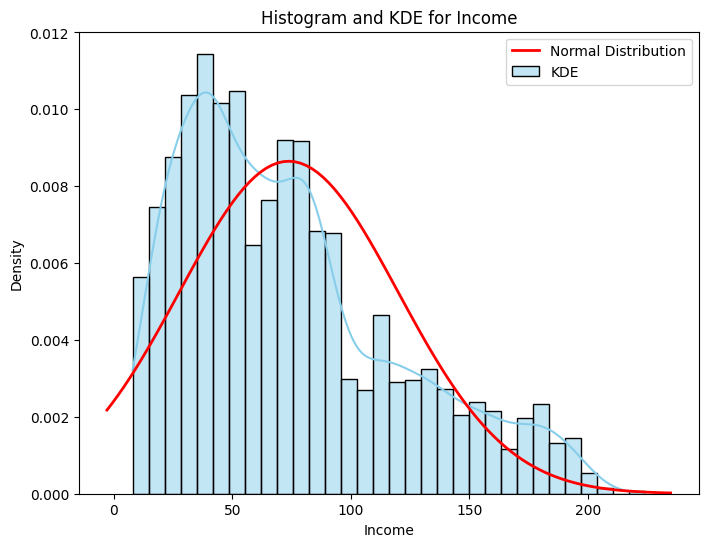

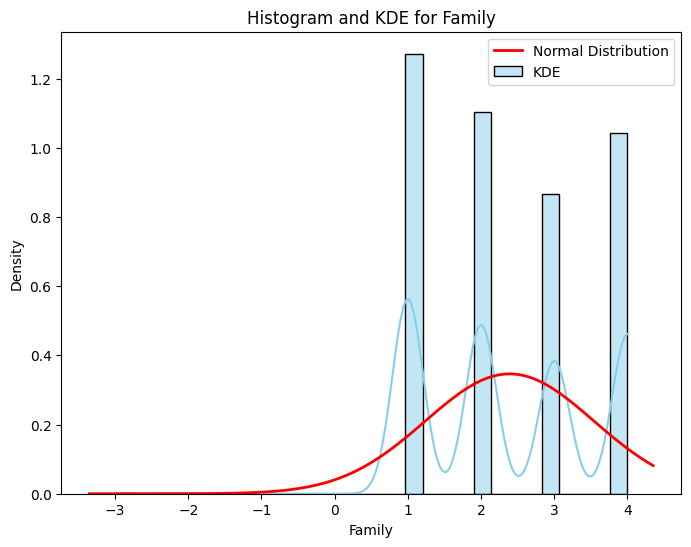

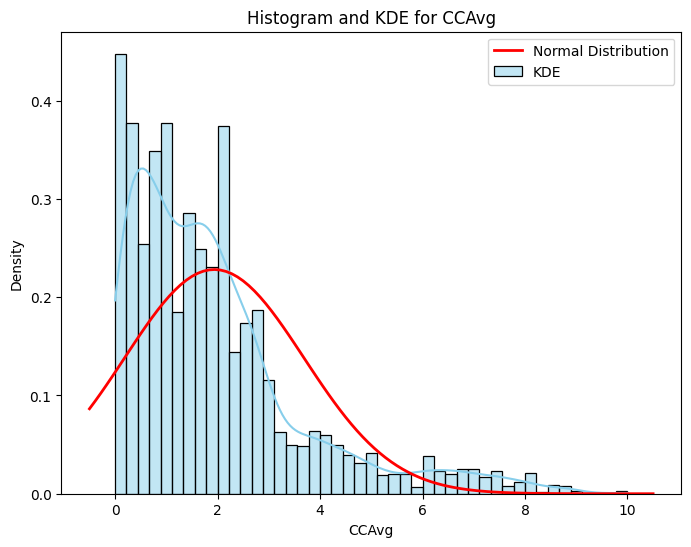

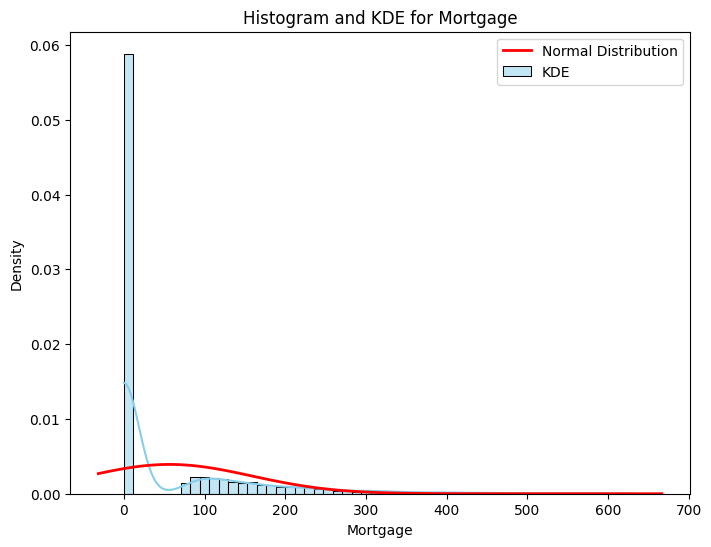


El Sesgo de la Edad es = -0.023024 por lo que es Simétrico
La Curtosis de la edad -1.161379 por lo que muestra un sesgo
La Comparación visual del histograma de Edad se muestra visualmente simétrico indicando un buen ajuste a la distribución de los datos

El Sesgo de Ingresos es 0.842132 que indica sesgo ligero a la derecha
La Curtosis de los ingresos es -0.046006 lo que indica que es Mesocúrtica
La Comparación visual del histograma de Ingresos muestra concentración de datos a la izquierda
lo cual es consistente con su sesgo positivo. El pico está algo aplanado en comparación con la curva de distribución normal
La curva KDE también refleja forma sesgada a la derecha

El Sesgo de Hipoteca es 2.104183  que indica sesgo fuerte a la derecha
La Curtosis de Hipoteca es 4.761586 lo que indica que es Leptocúrtica
La Comparación visual del histograma de Hipoteca presenta un sesgo a la derecha muy pronunciado
Una gran cantidad de valores se concentran cerca del cero


In [8]:
for col in num_cols:
    plt.figure(figsize=(8, 6))
    sns.histplot(Persloan_df[col], kde=True, stat='density', color='skyblue', label='KDE')

    # Calculate mean and standard deviation for the normal distribution curve
    mean = Persloan_df[col].mean()
    std = Persloan_df[col].std()

    # Generate points for the normal distribution curve
    xmin, xmax = plt.xlim()
    x = np.linspace(xmin, xmax, 100)
    p = norm.pdf(x, mean, std)

    # Overlay the normal distribution curve
    plt.plot(x, p, 'r', linewidth=2, label='Normal Distribution')

    plt.title(f'Histogram and KDE for {col}')
    plt.xlabel(col)
    plt.ylabel('Density')
    plt.legend()
    plt.show()
# Edad:
print("\nEl Sesgo de la Edad es = -0.023024 por lo que es Simétrico")
print(f"La Curtosis de la edad -1.161379 por lo que muestra un sesgo")
print(f"La Comparación visual del histograma de Edad se muestra visualmente simétrico indicando un buen ajuste a la distribución de los datos")

#Ingresos
print("\nEl Sesgo de Ingresos es 0.842132 que indica sesgo ligero a la derecha")
print(f"La Curtosis de los ingresos es -0.046006 lo que indica que es Mesocúrtica")
print(f"La Comparación visual del histograma de Ingresos muestra concentración de datos a la izquierda")
print(f"lo cual es consistente con su sesgo positivo. El pico está algo aplanado en comparación con la curva de distribución normal")
print(f"La curva KDE también refleja forma sesgada a la derecha")

#Hipoteca
print("\nEl Sesgo de Hipoteca es 2.104183  que indica sesgo fuerte a la derecha")
print(f"La Curtosis de Hipoteca es 4.761586 lo que indica que es Leptocúrtica")
print(f"La Comparación visual del histograma de Hipoteca presenta un sesgo a la derecha muy pronunciado")
print(f"Una gran cantidad de valores se concentran cerca del cero")


In [9]:
#Consideraciones
#Si la media es aproximadamente igual a la mediana, la distribución es simétrica.
#Si la media es mayor que la mediana, la distribución está sesgada a la derecha (asimetría positiva).
#Si la media es menor que la mediana, la distribución está sesgada a la izquierda (asimetría negativa).

print("\nAnaliza la posición de la media respecto a la mediana (Edad)")
print(f"La media es 45.56 y la mediana es 46 (centro del boxplot)")
print(f"Conclusión: Sugiere una distribución casi simétrica")

print("\nAnaliza la posición de la media respecto a la mediana (Ingresos)")
print(f"La media es 73.82 y la mediana es 64 (centro del boxplot)")
print(f"Conclusión: Sugiere una distribución sesgada a la derecha indicando la media hacia valores más altos")

print("\nAnaliza la posición de la media respecto a la mediana (Mortgage)")
print(f"La media es 56.65 y la mediana es 0 (centro del boxplot)")
print(f"Conclusión: Sugiere una distribución altamente sesgada a la derecha")


Analiza la posición de la media respecto a la mediana (Edad)
La media es 45.56 y la mediana es 46 (centro del boxplot)
Conclusión: Sugiere una distribución casi simétrica

Analiza la posición de la media respecto a la mediana (Ingresos)
La media es 73.82 y la mediana es 64 (centro del boxplot)
Conclusión: Sugiere una distribución sesgada a la derecha indicando la media hacia valores más altos

Analiza la posición de la media respecto a la mediana (Mortgage)
La media es 56.65 y la mediana es 0 (centro del boxplot)
Conclusión: Sugiere una distribución altamente sesgada a la derecha


8. Obtén las estadísticas descriptivas de las variables categóricas.
* Genera un gráfico de barras para cada variable. En las de alta cardinalidad, sólo incluye los 10 valores más relevantes.

Estadísticas descriptivas:
               Age   Experience       Income       Family        CCAvg  \
count  4944.000000  4944.000000  4944.000000  4944.000000  4944.000000   
mean     45.563107    20.336974    73.823625     2.390170     1.935975   
std      11.314587    11.306309    46.122628     1.151692     1.748313   
min      24.000000     0.000000     8.000000    -3.000000     0.000000   
25%      36.000000    11.000000    39.000000     1.000000     0.700000   
50%      46.000000    20.000000    64.000000     2.000000     1.500000   
75%      55.000000    30.000000    98.000000     3.000000     2.600000   
max      67.000000    43.000000   224.000000     4.000000    10.000000   

          Mortgage  
count  4944.000000  
mean     56.629248  
std     101.853990  
min       0.000000  
25%       0.000000  
50%       0.000000  
75%     101.000000  
max     635.000000  


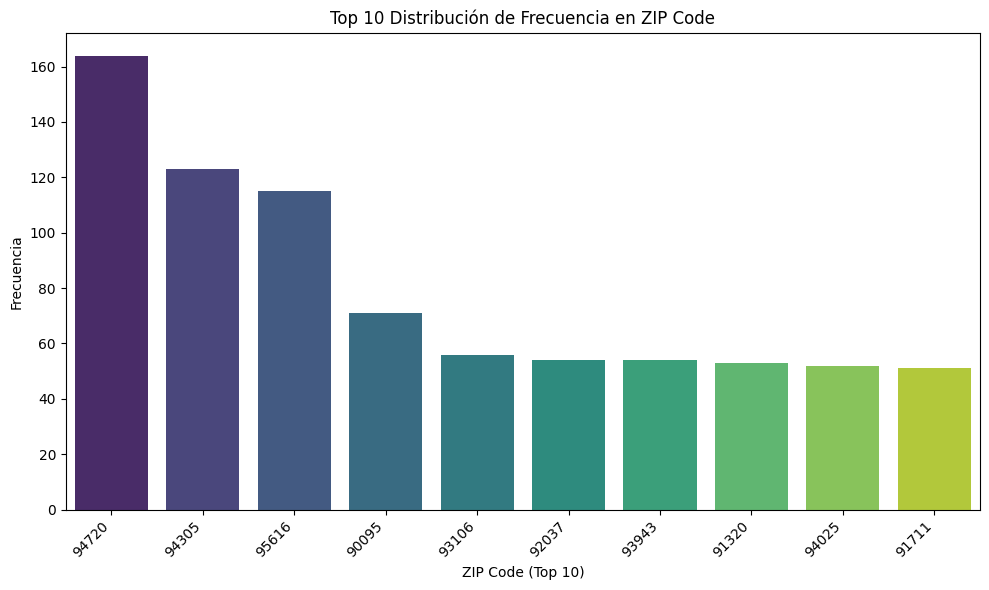

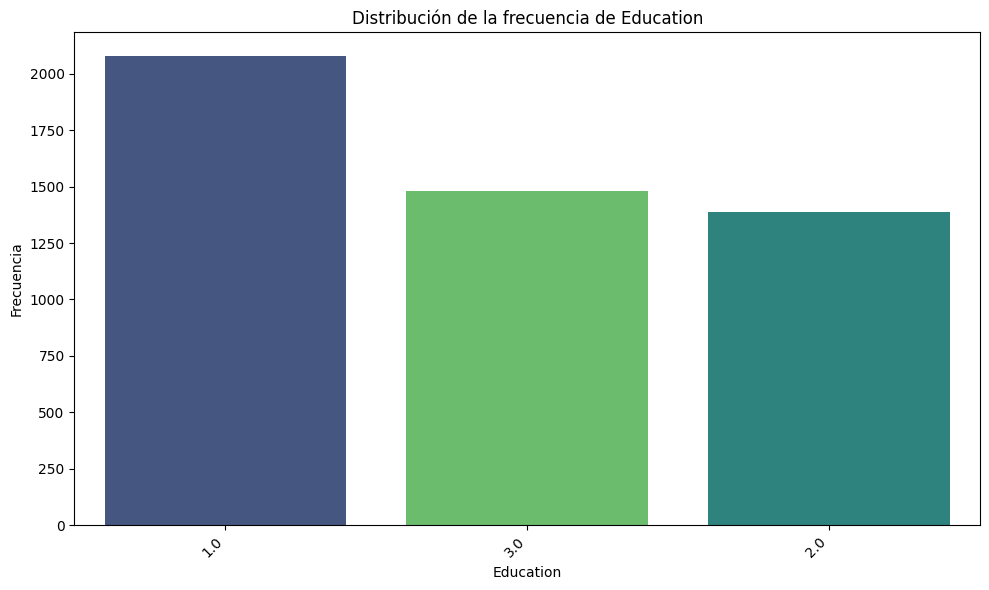

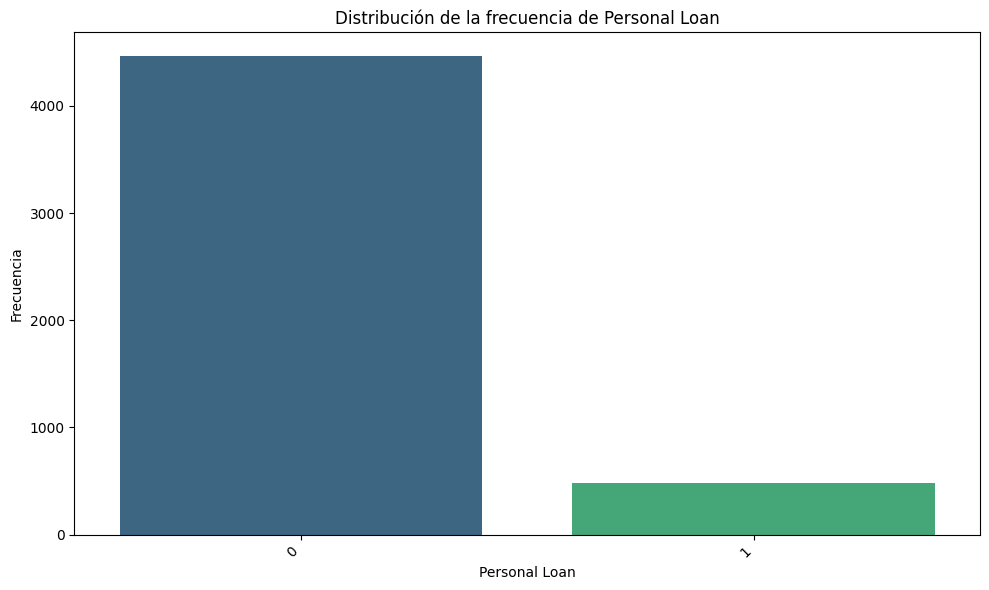

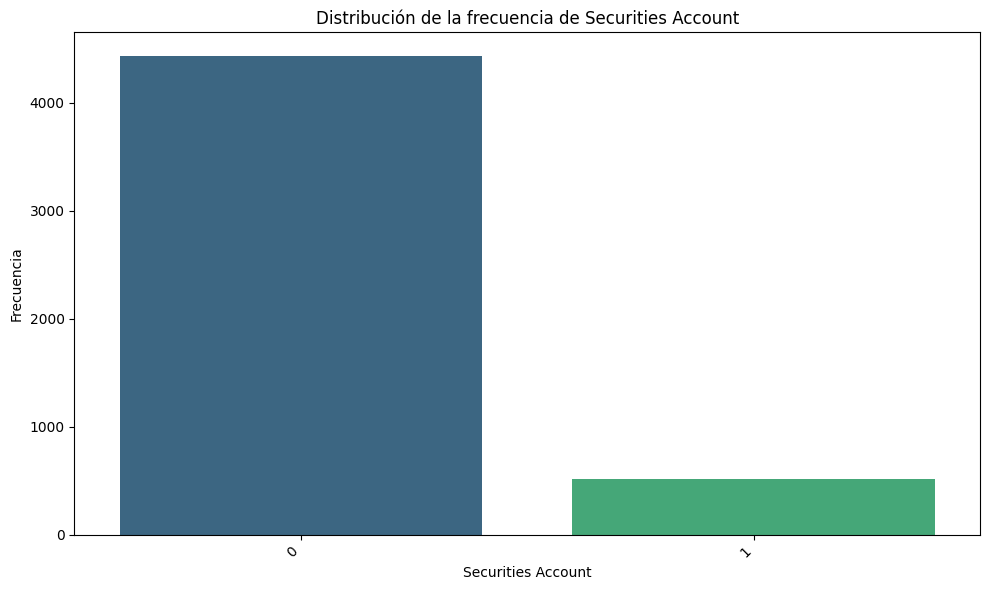

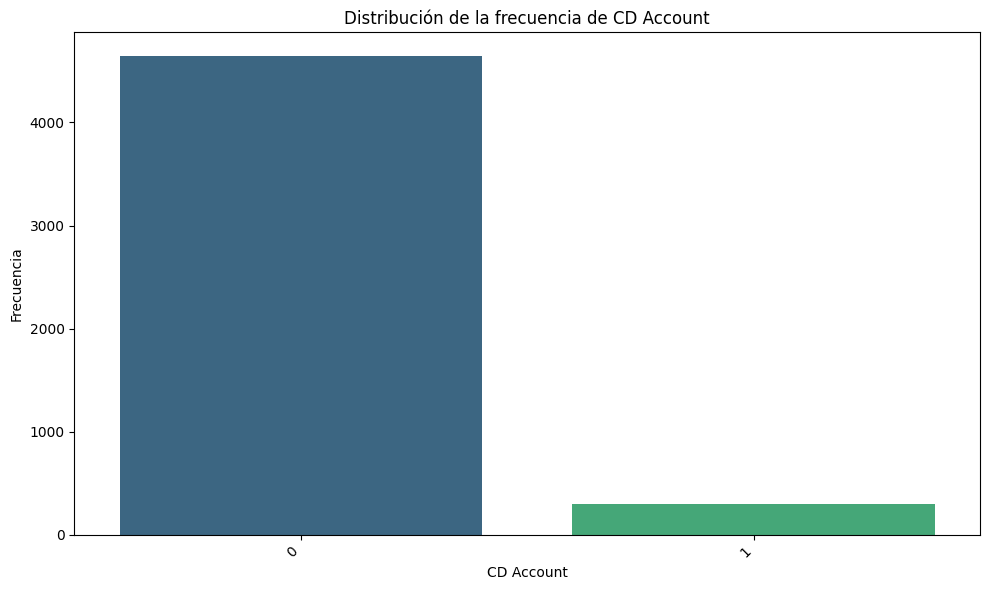

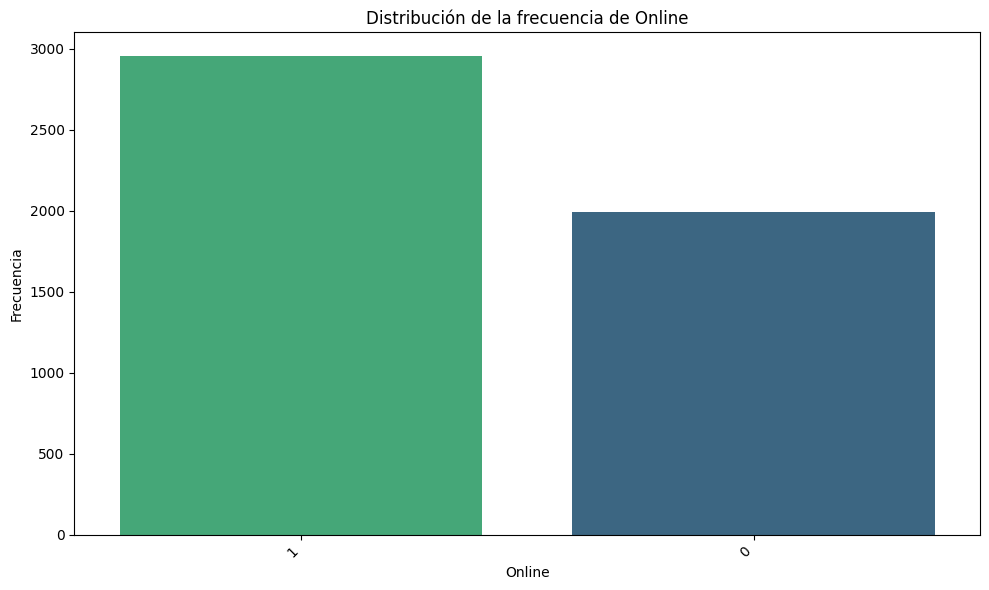

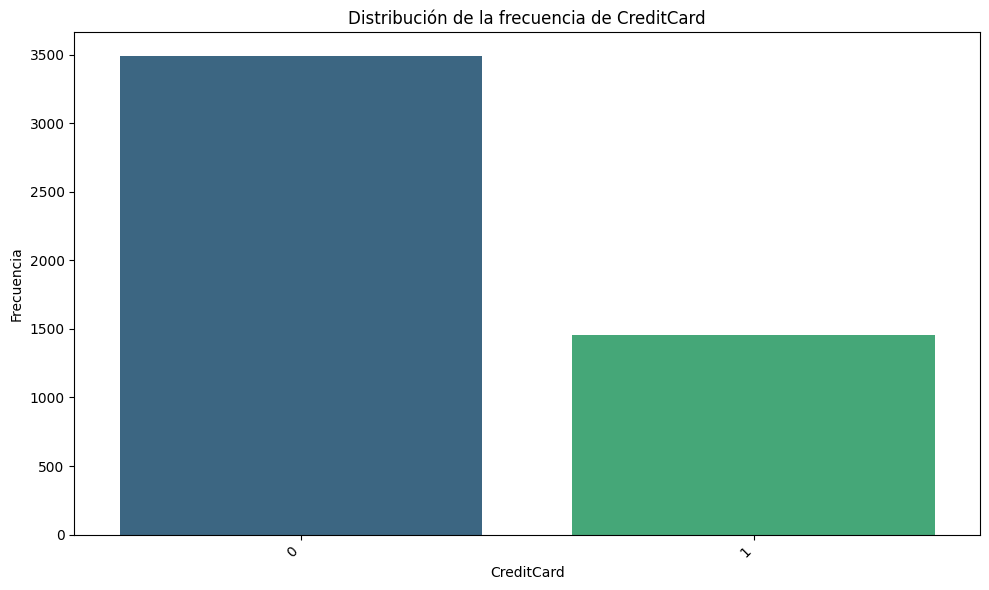

In [11]:
print("Estadísticas descriptivas:")
print(Persloan_df[num_cols].describe())

for col in cat_cols:
    plt.figure(figsize=(10, 6))
    if Persloan_df[col].nunique() > 10:
        # Plot top 10
        top_10 = Persloan_df[col].value_counts().nlargest(10)
        sns.barplot(x=top_10.index.astype(str), y=top_10.values, palette='viridis',hue=top_10.index.astype(str), legend=False)
        plt.title(f'Top 10 Distribución de Frecuencia en {col}')
        plt.xlabel(f'{col} (Top 10)')
        plt.ylabel('Frecuencia')
    else:
        # For low-cardinality columns, plot all values
        sns.countplot(x=col, data=Persloan_df, palette='viridis', order=Persloan_df[col].value_counts().index, hue=col, legend=False)
        plt.title(f'Distribución de la frecuencia de {col}')
        plt.xlabel(col)
        plt.ylabel('Frecuencia')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()


# Análisis exploratorio de datos (bivariado)

9. Obtén la matriz de gráficos de dispersión (*scatter matrix*) de todas las variables numéricas.
* Observa las relaciones entre las variables, selecciona un par representativo y describe los patrones o tendencias que sean evidentes.
* Para cuantificar la fuerza y dirección de las relaciones observadas, genera un mapa de calor con los valores de correlación de *Pearson*. ¿El valor numérico obtenido del par seleccionado se corresponde con lo esperado?

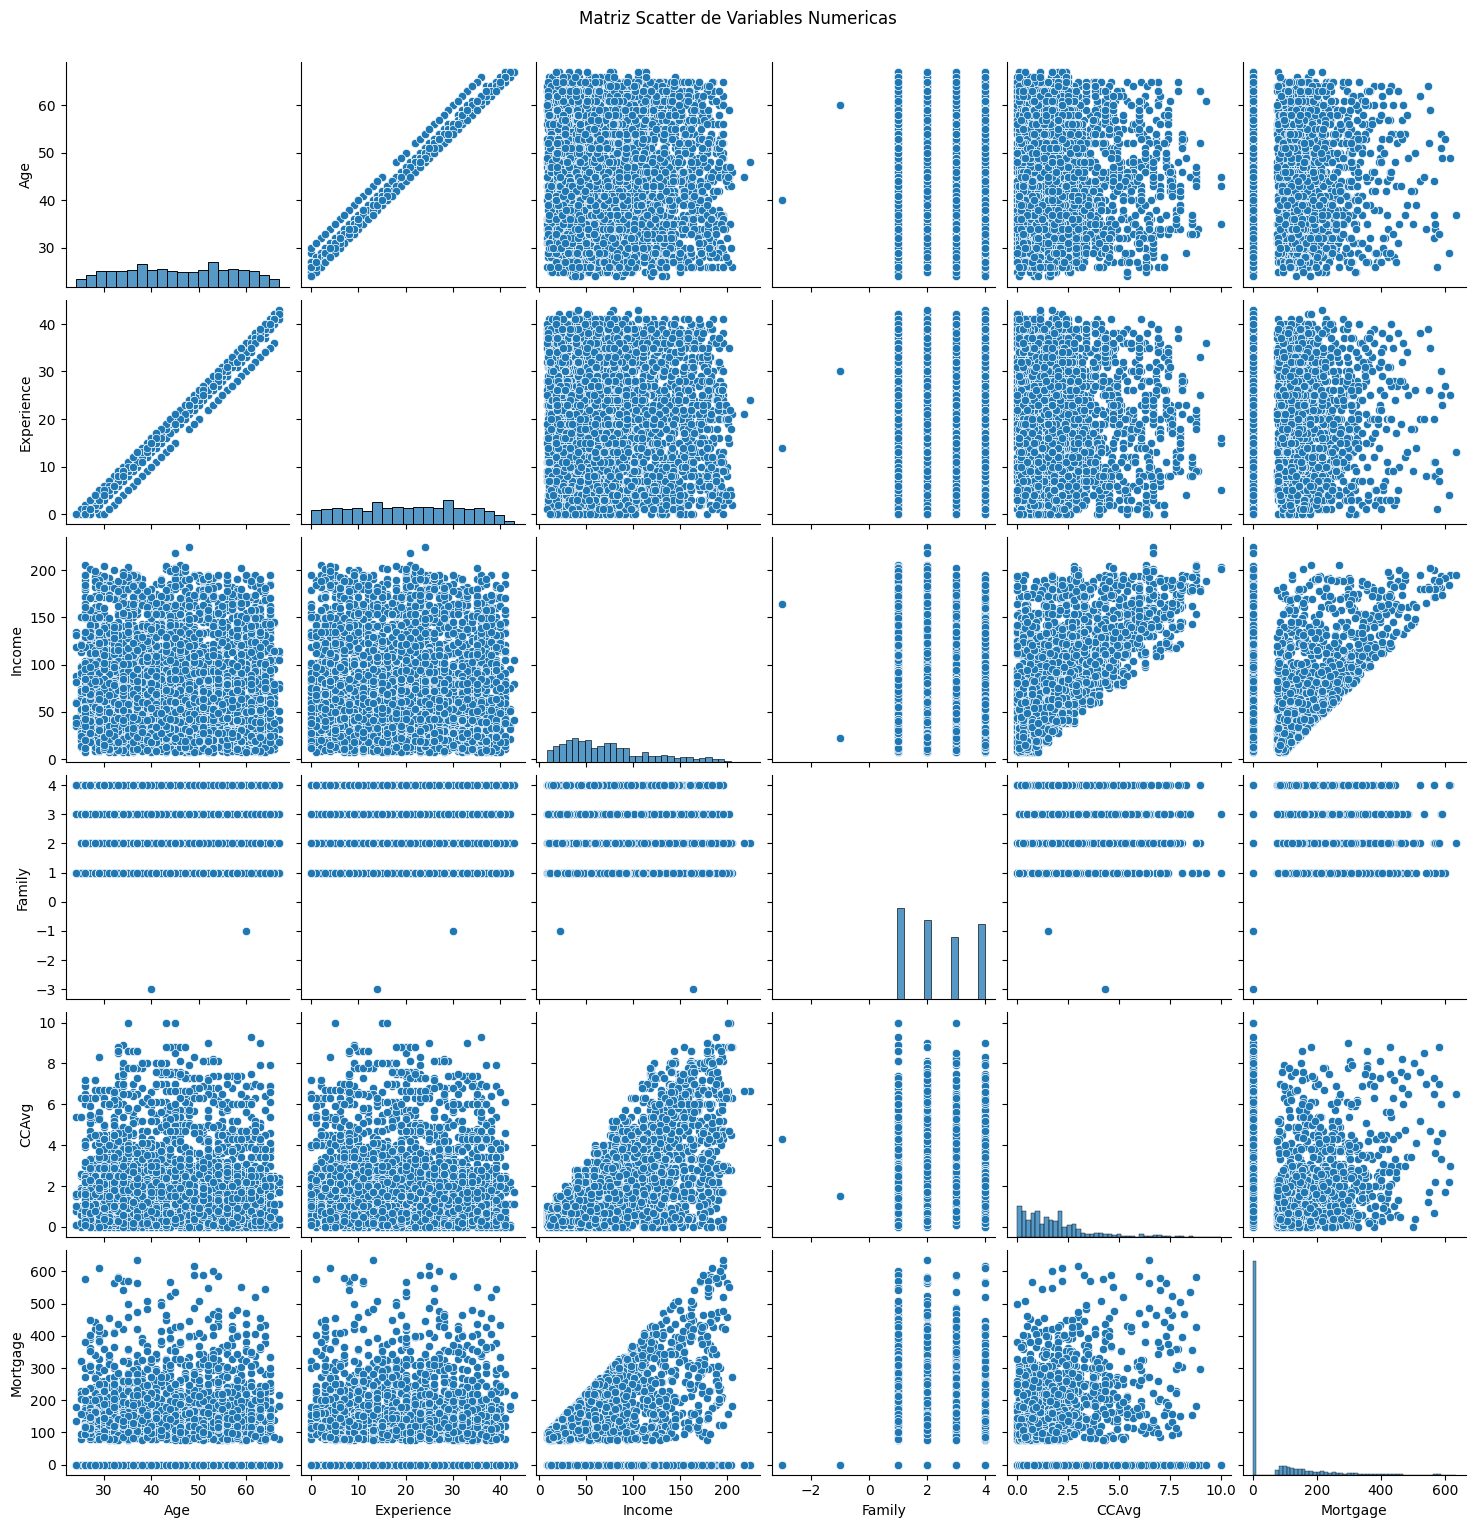


### Patrones o tendencias evidentes en Matriz Scatter:
1. La edad vs la experiencia, muestra una relación lineal positiva, lo que es esperado ya que regularmente la experiencia aumenta con la edad.
2. La edad y los ingresos muestran una amplia dispersión, lo que sugiere la ausencia de una correlación lineal fuerte.
3. Ingresos vs CCAvg, muestra una corelación moderadamente positiva al igual que la tendencia de gasto en tarjeta de crédito.
4. Ingresos vs Prestamo personal, muestra que los clientes con ingresos más altos tienen una mayor probabilidad de aceptar un préstamo personal.
5. Hipoteca, muestra que la tendencia de clientes con hipoteca es demasiado baja.
6  Otros datos no muestran una correlacion lineal fuerte.



Mapa de Calor


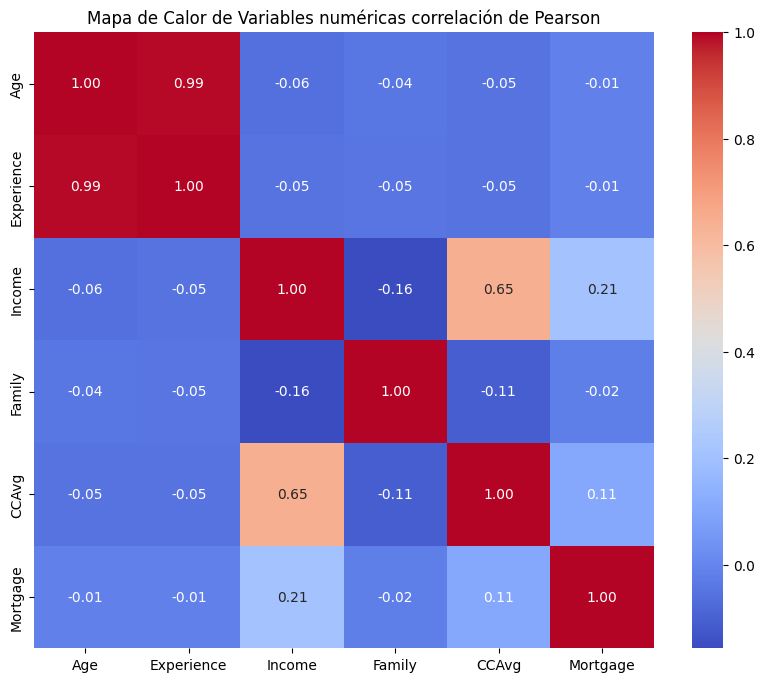


Corresponde con lo esperado


In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.pairplot(Persloan_df[num_cols])
plt.suptitle('Matriz Scatter de Variables Numericas', y=1.02)
plt.show()

print("""
### Patrones o tendencias evidentes en Matriz Scatter:
1. La edad vs la experiencia, muestra una relación lineal positiva, lo que es esperado ya que regularmente la experiencia aumenta con la edad.
2. La edad y los ingresos muestran una amplia dispersión, lo que sugiere la ausencia de una correlación lineal fuerte.
3. Ingresos vs CCAvg, muestra una corelación moderadamente positiva al igual que la tendencia de gasto en tarjeta de crédito.
4. Ingresos vs Prestamo personal, muestra que los clientes con ingresos más altos tienen una mayor probabilidad de aceptar un préstamo personal.
5. Hipoteca, muestra que la tendencia de clientes con hipoteca es demasiado baja.
6  Otros datos no muestran una correlacion lineal fuerte.

""")
print("\nMapa de Calor")
plt.figure(figsize=(10, 8))
sns.heatmap(Persloan_df[num_cols].corr(method='pearson'), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Mapa de Calor de Variables numéricas correlación de Pearson')
plt.show()

print("\nCorresponde con lo esperado")

10. Realiza un análisis de todas las variables del dataset con respecto a la variable de salida `Personal Loan`.
* Variables numéricas: Genera box plots para comparar la distribución de cada variable según los valores de `Personal Loan`.
* Variables categóricas (sin considerar `ZIP Code`): Genera gráficos de barras apiladas que muestren la distribución relativa de `Personal Loan` dentro de cada categoría de la variable.
* Para cada grupo de variables (numéricas y categóricas), comenta al menos un hallazgo o patrón relevante observado en los gráficos generados.


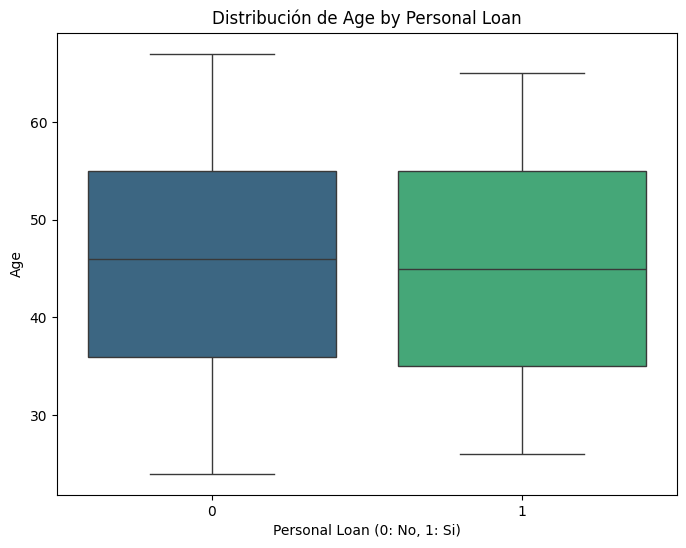

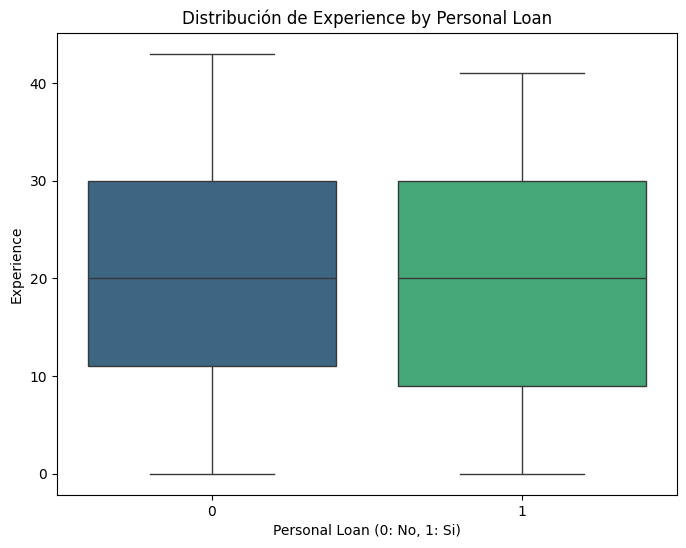

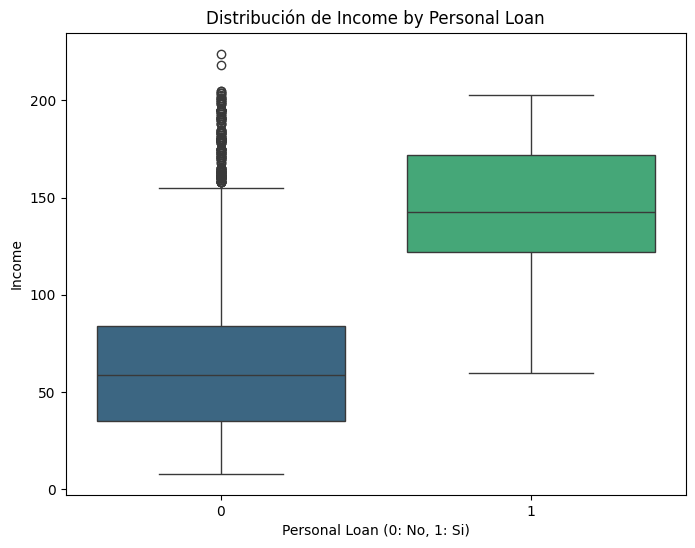

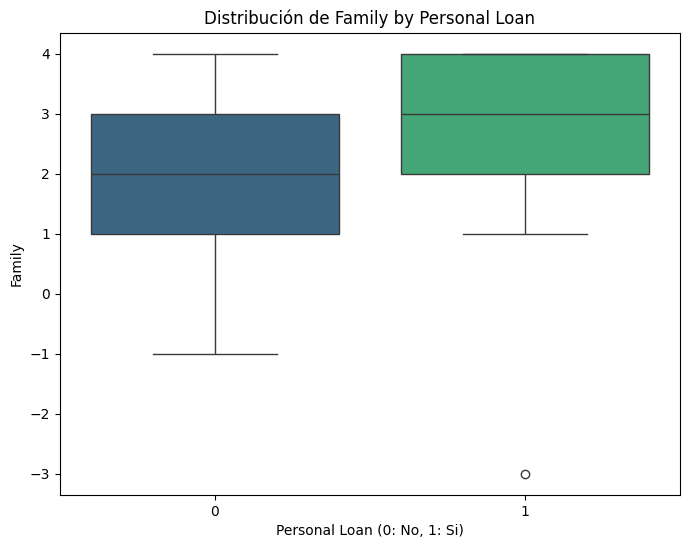

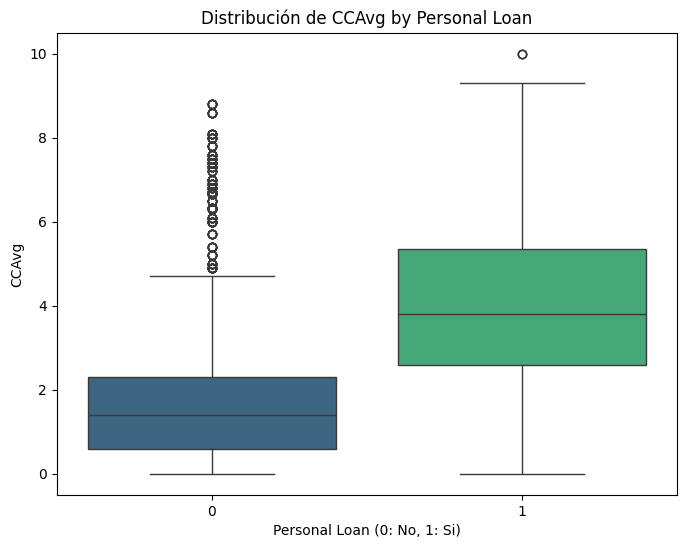

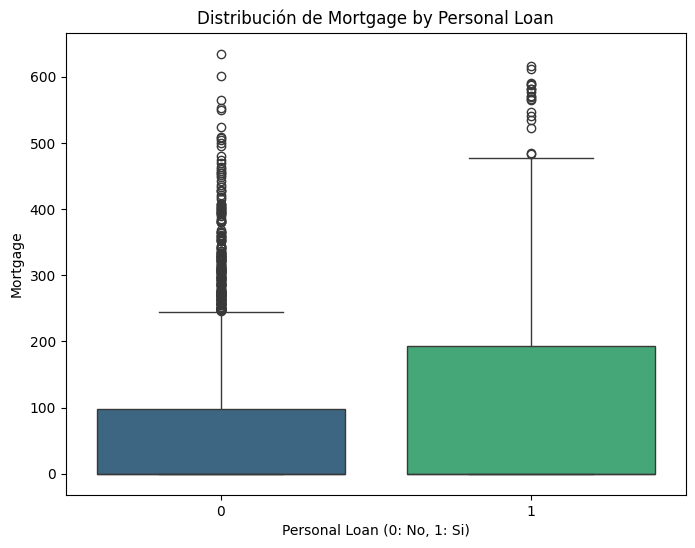

In [13]:
##Genera box plots para comparar la distribución de cada variable según los valores de Personal Loan
for col in num_cols:
    plt.figure(figsize=(8, 6))
    sns.boxplot(x='Personal Loan', y=col, data=Persloan_df, palette='viridis', hue='Personal Loan', legend=False)
    plt.title(f'Distribución de {col} by Personal Loan')
    plt.xlabel('Personal Loan (0: No, 1: Si)')
    plt.ylabel(col)
    plt.show()


<Figure size 1000x600 with 0 Axes>

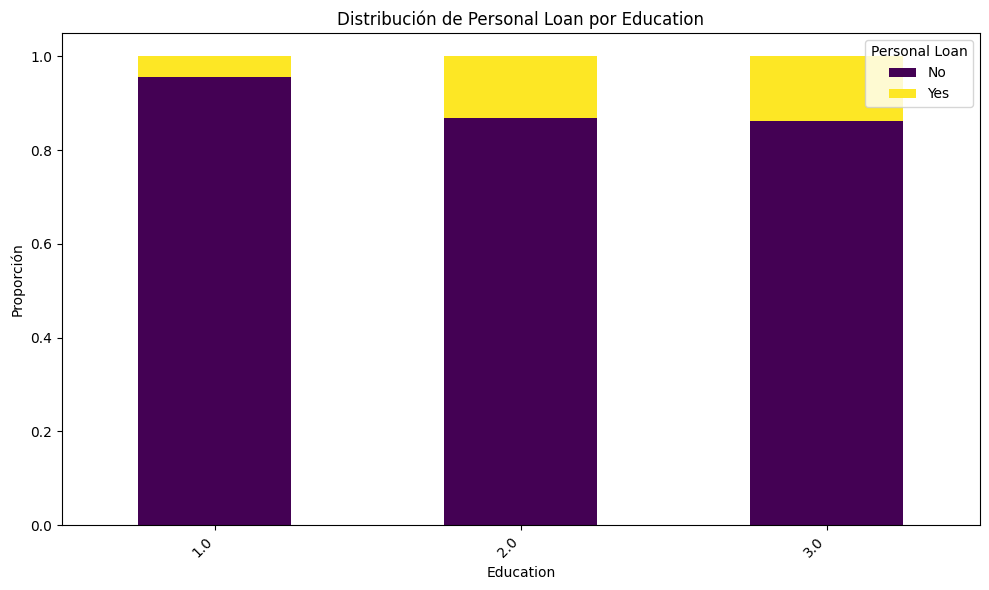

<Figure size 1000x600 with 0 Axes>

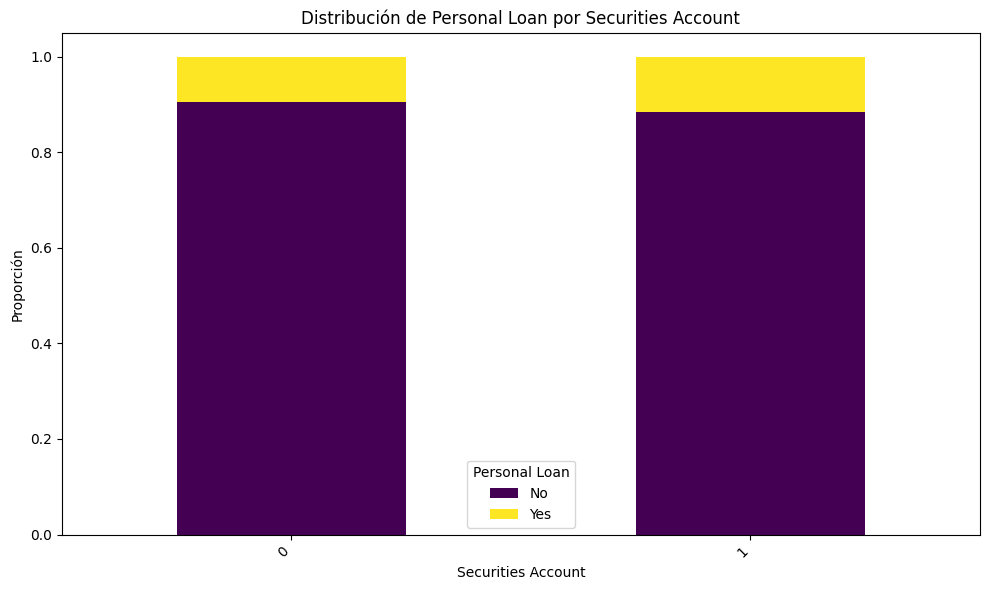

<Figure size 1000x600 with 0 Axes>

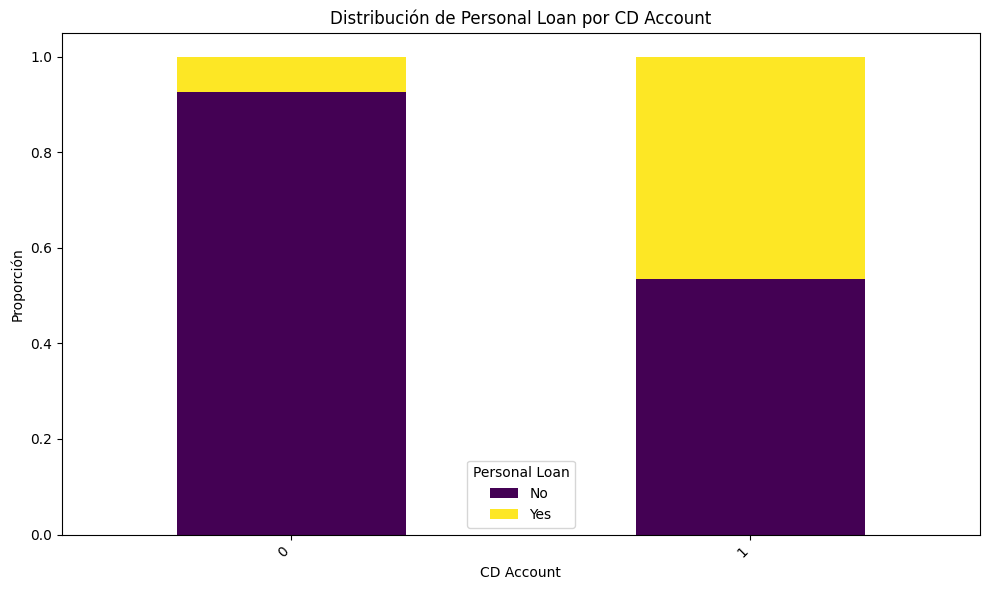

<Figure size 1000x600 with 0 Axes>

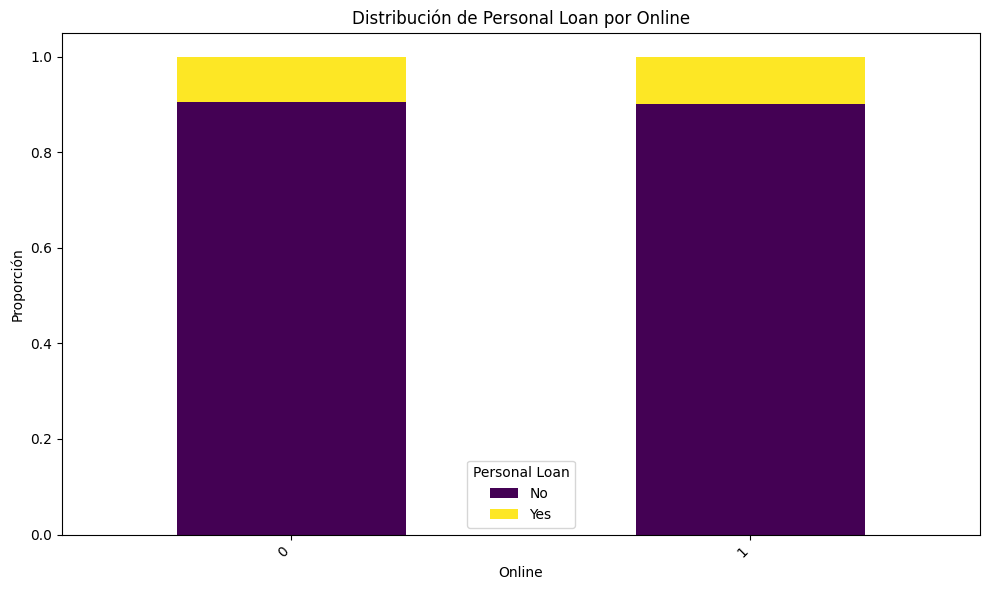

<Figure size 1000x600 with 0 Axes>

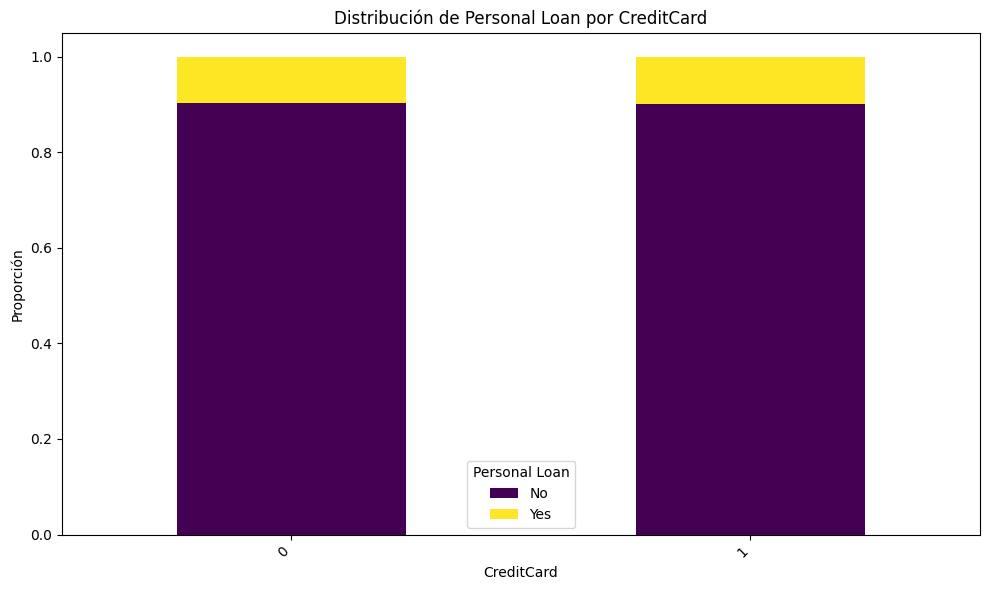

In [14]:
  ##Genera gráficos de barras apiladas que muestren la distribución relativa de Personal Loan dentro de cada categoría de la variable.
  catcols_plot = [col for col in cat_cols if col != 'ZIP Code' and col != 'Personal Loan']

for col in catcols_plot:
    plt.figure(figsize=(10, 6))
    ct = pd.crosstab(Persloan_df[col], Persloan_df['Personal Loan'], normalize='index')

    # Plot bar chart
    ct.plot(kind='bar', stacked=True, colormap='viridis', figsize=(10, 6))
    plt.title(f'Distribución de Personal Loan por {col}')
    plt.xlabel(col)
    plt.ylabel('Proporción')
    plt.xticks(rotation=45, ha='right')
    plt.legend(title='Personal Loan', labels=['No', 'Yes'])
    plt.tight_layout()
    plt.show()


In [15]:
##Comenta al menos un hallazgo o patrón relevante observado en los gráficos generados.
print("""Hallazgos
Educación vs. Préstamo Personal: Parece haber una diferencia notable en la aceptación de préstamos
personales según el nivel educativo. Los clientes con un nivel de Educación de posgrado
parecen tener una mayor proporción de aceptación de préstamos personales en comparación con los
graduados y universitarios.
""")
print("""
Tarjeta de Crédito vs. Préstamo Personal: No existe una diferencia significativa en la proporción de
aceptación de préstamos personales entre los clientes que poseen una Tarjeta de Crédito y aquellos que no
Esto indica que el simple hecho de poseer una tarjeta de crédito no influye de manera determinante en aceptar un préstamo personal.
""")


Hallazgos
Educación vs. Préstamo Personal: Parece haber una diferencia notable en la aceptación de préstamos 
personales según el nivel educativo. Los clientes con un nivel de Educación de posgrado
parecen tener una mayor proporción de aceptación de préstamos personales en comparación con los 
graduados y universitarios.


Tarjeta de Crédito vs. Préstamo Personal: No existe una diferencia significativa en la proporción de
aceptación de préstamos personales entre los clientes que poseen una Tarjeta de Crédito y aquellos que no
Esto indica que el simple hecho de poseer una tarjeta de crédito no influye de manera determinante en aceptar un préstamo personal.

